In [2]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [3]:
crime_data = pd.read_csv("s3://ia-340-fa25-ibrahim/SPD_Crime_Data__2008-Present.csv") # Loading data from S3 bucket
crime_data.head() # Loading the first bits of data

,Report Number,Report DateTime,Offense ID,Offense Date,NIBRS Group AB,NIBRS Crime Against Category,Offense Sub Category,Shooting Type Group,Block Address,Latitude,Longitude,Beat,Precinct,Sector,Neighborhood,Reporting Area,Offense Category,NIBRS Offense Code Description,NIBRS_offense_code
0,2013-217957,06/22/2013 09:29:00 PM,7686115988,06/22/2013 09:29:00 PM,A,PERSON,AGGRAVATED ASSAULT,-,-,-1.0,-1.0,F1,Southwest,F,-,1678,VIOLENT CRIME,Aggravated Assault,13A
1,2009-237520,07/08/2009 05:54:00 PM,7641304087,07/08/2009 07:00:00 AM,A,PROPERTY,LARCENY-THEFT,-,11XX BLOCK OF WESTERN AVE,47.60530026,-122.338327485671,K1,West,K,-,469,PROPERTY CRIME,Theft of Motor Vehicle Parts or Accessories,23G
2,2015-079168,03/10/2015 02:06:00 PM,7680665743,03/10/2015 01:11:00 PM,A,PROPERTY,LARCENY-THEFT,-,44XX BLOCK OF 4TH AVE S,47.56380429,-122.329368514925,O2,South,O,-,11067,PROPERTY CRIME,Shoplifting,23C
3,2022-163752,06/26/2022 08:43:59 PM,34519102321,06/26/2022 06:16:00 PM,B,SOCIETY,TRESPASS,-,REDACTED,REDACTED,REDACTED,N2,North,N,NORTHGATE,REDACTED,ALL OTHER,Trespass of Real,90J
4,2017-268444,07/23/2017 12:41:00 AM,7637289721,07/22/2017 11:55:00 PM,A,PERSON,ASSAULT OFFENSES,-,1XX BLOCK OF YESLER WAY,47.60172211,-122.334038699999,K1,West,K,DOWNTOWN COMMERCIAL,12793,ALL OTHER,Simple Assault,13B


In [4]:
crime_data.shape

(1476264, 19)

In [5]:
crime_data.info() # shows the data types and number of null values. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476264 entries, 0 to 1476263
Data columns (total 19 columns):
 #   Column                          Non-Null Count    Dtype 
---  ------                          --------------    ----- 
 0   Report Number                   1476264 non-null  object
 1   Report DateTime                 1476264 non-null  object
 2   Offense ID                      1476264 non-null  int64 
 3   Offense Date                    1476264 non-null  object
 4   NIBRS Group AB                  1476264 non-null  object
 5   NIBRS Crime Against Category    1476264 non-null  object
 6   Offense Sub Category            1476264 non-null  object
 7   Shooting Type Group             1476264 non-null  object
 8   Block Address                   1476264 non-null  object
 9   Latitude                        1476264 non-null  object
 10  Longitude                       1476264 non-null  object
 11  Beat                            1476264 non-null  object
 12  Precinct      

In [6]:
crime_data.head

<bound method NDFrame.head of         Report Number         Report DateTime   Offense ID  \
0         2013-217957  06/22/2013 09:29:00 PM   7686115988   
1         2009-237520  07/08/2009 05:54:00 PM   7641304087   
2         2015-079168  03/10/2015 02:06:00 PM   7680665743   
3         2022-163752  06/26/2022 08:43:59 PM  34519102321   
4         2017-268444  07/23/2017 12:41:00 AM   7637289721   
...               ...                     ...          ...   
1476259   2017-147966  04/28/2017 04:29:00 PM   7638297923   
1476260   2014-181379  06/08/2014 05:00:00 AM   7693082371   
1476261   2018-257393  07/13/2018 11:58:00 AM   7629687971   
1476262   2019-003825  01/03/2019 07:03:00 PM   7698597798   
1476263   2017-143436  04/24/2017 10:18:00 PM   7666418313   

                   Offense Date NIBRS Group AB NIBRS Crime Against Category  \
0        06/22/2013 09:29:00 PM              A                       PERSON   
1        07/08/2009 07:00:00 AM              A                     

In [7]:
crime_data.isnull().sum() #show the number of rows containing null value

Report Number                     0
Report DateTime                   0
Offense ID                        0
Offense Date                      0
NIBRS Group AB                    0
NIBRS Crime Against Category      0
Offense Sub Category              0
Shooting Type Group               0
Block Address                     0
Latitude                          0
Longitude                         0
Beat                              0
Precinct                          0
Sector                            0
Neighborhood                      0
Reporting Area                    0
Offense Category                  0
NIBRS Offense Code Description    0
NIBRS_offense_code                0
dtype: int64

In [8]:
crime_data = crime_data.dropna() #drop null values
crime_data.isnull().sum()

Report Number                     0
Report DateTime                   0
Offense ID                        0
Offense Date                      0
NIBRS Group AB                    0
NIBRS Crime Against Category      0
Offense Sub Category              0
Shooting Type Group               0
Block Address                     0
Latitude                          0
Longitude                         0
Beat                              0
Precinct                          0
Sector                            0
Neighborhood                      0
Reporting Area                    0
Offense Category                  0
NIBRS Offense Code Description    0
NIBRS_offense_code                0
dtype: int64

In [9]:
crime_data = crime_data[['Sector', 'Beat', 'Reporting Area', 'Offense Category']]
crime_data.head()

,Sector,Beat,Reporting Area,Offense Category
0,F,F1,1678,VIOLENT CRIME
1,K,K1,469,PROPERTY CRIME
2,O,O2,11067,PROPERTY CRIME
3,N,N2,REDACTED,ALL OTHER
4,K,K1,12793,ALL OTHER


In [9]:
crime_data = crime_data.rename(columns={"Report DateTime": "Date",}) 
crime_data.head()

,Sector
0,F
1,K
2,O
3,N
4,K


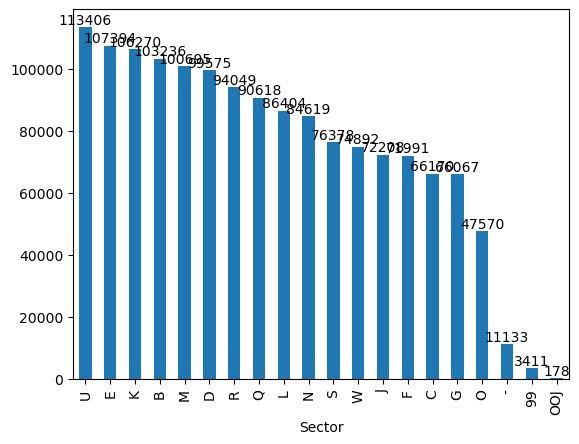

In [20]:
crime_data['Sector'].value_counts().plot.bar()
counts = crime_data['Sector'].value_counts()
ax = counts.plot.bar()
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

#crime_data.hist(layout=(2,2), figsize=(10, 5), sharey=False, sharex=False, bins=50)

In [ ]:
from sklearn.preprocessing import LabelEncoder

crime_data = pd.read_csv("s3://ia-340-fa25-ibrahim/SPD_Crime_Data__2008-Present.csv")

encoder = LabelEncoder()
crime_data['Precinct_encoded'] = encoder.fit_transform(crime_data["Precinct"])

print(crime_data)

#sum_cases_by_sector = crime_data.groupby('Precinct')['Sector'].sum() # calculate the total deaths per day
#sum_cases_by_sector.nlargest(10).plot.bar() # use a bar chart to show the results of the top 10 countries 